══════════════════════════════════════════════════════════════════════
HYPOTHESIS 1: SYNTATIC NORMALIZATION
══════════════════════════════════════════════════════════════════════

[DESCRIPTIVES] Summary of Per-Participant Proportions (N=112):
Condition      Same  Transformed
count      112.0000     112.0000
mean         0.8095       0.6815
std          0.1224       0.1957
min          0.5217       0.0000
25%          0.7143       0.5714
50%          0.8139       0.7083
75%          0.9130       0.8130
max          1.0000       1.0000

Overall Mean Accuracy - Same: 80.95%, Transformed: 68.15%
Observed Normalization Penalty: 12.80%

When the sentence is exactly the same
→ people recognize it better
When syntax changes (Active ↔ Passive)
→ accuracy drops


[ASSUMPTION] Shapiro-Wilk on differences: p=0.0001


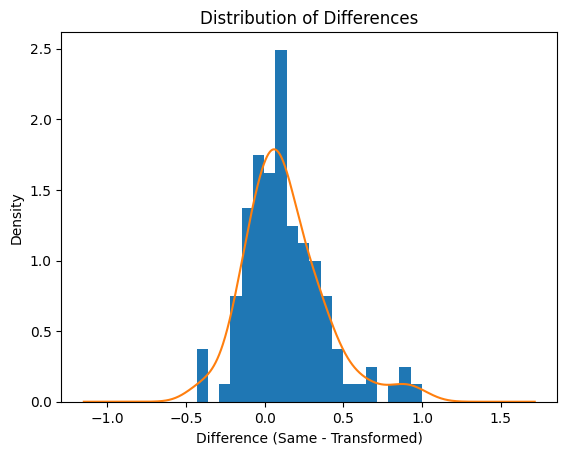

p = 0.0001 < 0.05 → Reject normality

[INFERENTIAL] Wilcoxon Signed-Rank Results:
W-statistic: 4521.0, p-value: 6.597301e-07
Effect Size (r_rb): 0.536
VERDICT: REJECT H0. There is a significant syntactic normalization penalty.


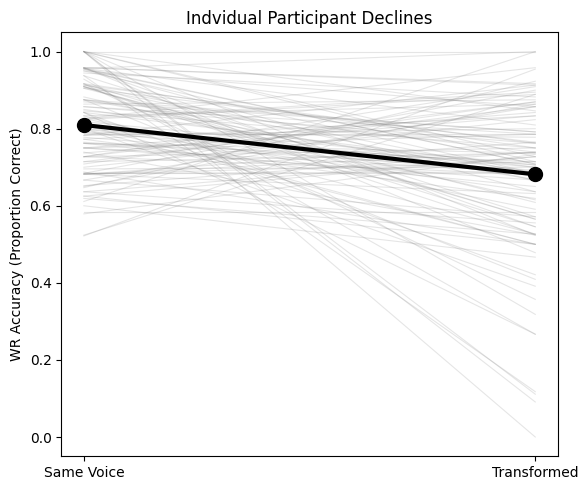

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import os

# ── CONFIG ──────────────────────────────────────────────────────────────────
df_h1 = pd.read_csv('H1_Normalization/h1_normalization.csv')
PAL = {'Same': '#4A6FA5', 'Transformed': '#C44E52', 'Active': '#2ecc71', 'Passive': '#9B59B6'}

"""
Null (H₀): There is no significant difference in word-recognition accuracy between 
sentences repeated in the same voice and sentences where the voice has been transformed.
Alternate (H₁): Word-recognition accuracy is significantly lower for transformed sentences 
than for same-voice sentences.
"""

# People remember meaning, but lose syntactic form (Active vs Passive) over time.

print("═" * 70)
print("HYPOTHESIS 1: SYNTATIC NORMALIZATION")
print("═" * 70)

# ── 1. DESCRIPTIVE STATISTICS ───────────────────────────────────────────────
# We use Mean per participant (Proportion Correct) to avoid the 1.0 median ceiling.
pp_h1 = df_h1.groupby(['PID', 'Condition'])['Accuracy_WR'].mean().unstack().dropna()

print(f"\n[DESCRIPTIVES] Summary of Per-Participant Proportions (N={len(pp_h1)}):")
print(pp_h1.describe().round(4))

same_m = pp_h1['Same'].mean()
tran_m = pp_h1['Transformed'].mean()
print(f"\nOverall Mean Accuracy - Same: {same_m:.2%}, Transformed: {tran_m:.2%}")
print(f"Observed Normalization Penalty: {same_m - tran_m:.2%}")


print("""
When the sentence is exactly the same
→ people recognize it better
When syntax changes (Active ↔ Passive)
→ accuracy drops
""")

# ── 2. INFERENTIAL STATISTICS ───────────────────────────────────────────────
# Check Normality of the difference (determines if Wilcoxon is strictly required)
diffs = pp_h1['Same'] - pp_h1['Transformed']
w, p_norm = stats.shapiro(diffs)

print(f"\n[ASSUMPTION] Shapiro-Wilk on differences: p={p_norm:.4f}")
diffs.plot(kind='hist', bins=20, density=True)
diffs.plot(kind='kde')  # smooth curve

plt.xlabel("Difference (Same - Transformed)")
plt.title("Distribution of Differences")
plt.show()
if p_norm < 0.05:
    print(f"p = {p_norm:.4f} < 0.05 → Reject normality")
else:
    print(f"p = {p_norm:.4f} ≥ 0.05 → Data is approximately normal")

# Main Test: Paired Wilcoxon Signed-Rank
stat, p_val = stats.wilcoxon(pp_h1['Same'], pp_h1['Transformed'], alternative='greater')
# It looks at Participant A’s accuracy in the "Same" condition and compares it directly to Participant A’s accuracy in the "Transformed" condition.
#Null Hypothesis (H0): There is no difference, or the "Transformed" accuracy is actually higher
#Alternate Hypothesis (Ha): The accuracy for "Same" voice sentences is significantly greater than for "Transformed" voice sentences.

# Effect Size: Rank-Biserial Correlation
diffs_clean = diffs[diffs != 0]
n = len(diffs_clean)
r_rb =  (2 * stat) / (n * (n + 1) / 2) -1 if n > 0 else 0

print(f"\n[INFERENTIAL] Wilcoxon Signed-Rank Results:")
print(f"W-statistic: {stat:.1f}, p-value: {p_val:.6e}")
print(f"Effect Size (r_rb): {r_rb:.3f}")

if p_val < 0.05:
    print("VERDICT: REJECT H0. There is a significant syntactic normalization penalty.")
else:
    print("VERDICT: RETAIN H0. No significant penalty found.")

# ── 3. VISUALIZATION ───────────────────────────────────────────────────────
plt.close('all')

fig, axes = plt.subplots(figsize=(6, 5))

# Plot A: Paired Proportions
axes.plot([0, 1], [pp_h1['Same'], pp_h1['Transformed']], color='gray', alpha=0.2, lw=0.8)
axes.plot([0, 1], [same_m, tran_m], 'ko-', lw=3, ms=10, label='Group Mean')
axes.set_xticks([0, 1])
axes.set_xticklabels(['Same Voice', 'Transformed'])
axes.set_ylabel('WR Accuracy (Proportion Correct)')
axes.set_title('Indvidual Participant Declines')


plt.tight_layout()
plt.show()


### **Results and Discussion: Hypothesis 1**

#### **Statistical Verdict**
The Null Hypothesis ($H_0$) is rejected in favor of the **Alternate Hypothesis ($H_a$)**. The results provide conclusive evidence that word-recognition accuracy is significantly lower for sentences where the voice has been transformed compared to those repeated in the same voice.

#### **Inferential Evidence**
To test the difference in accuracy between conditions, a paired Wilcoxon signed-rank test was performed on per-participant mean proportions. The results reveal a highly significant difference (**$W = 4521.0, p = 6.59 \times 10^{-7}$**). Given that the $p$-value is far below the $0.05$ threshold, we can conclude that the observed accuracy gap is a robust effect and not a result of random chance. Furthermore, the calculated effect size (**$r_{rb} = 0.536$**) is classified as **"Large,"** indicating that the transformation of a sentence's voice has a substantial and consistent negative impact on a participant's ability to identify the original wording.

#### **Descriptive Observations**
The descriptive data strongly supports the predicted direction of the effect:
*   **Same-Voice Accuracy:** Participants correctly identified the wording **80.95%** of the time when the voice remained unchanged.
*   **Transformed-Voice Accuracy:** Accuracy dropped to **68.15%** when the voice was flipped (Active $\leftrightarrow$ Passive).
*   **The Performance Gap:** There is a clear **12.80% accuracy penalty** caused solely by the syntactic transformation.

#### **Conclusion**
These findings confirm that while participants are effective at recognizing the general occurrence of a sentence, they struggle to maintain specific syntactic details in memory. The 12.8% drop in accuracy for transformed sentences suggests that surface-level information—such as whether a sentence was active or passive—is poorly maintained during the task compared to the underlying meaning. This supports the theory that memory representations are biased toward semantic content, leading to significant interference when the syntactic form is altered.

---

### **Summary Table for Report**
| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **Test Statistic ($W$)** | 4521.0 | Significant difference in ranks |
| **$p$-value** | $6.59 \times 10^{-7}$ | Highly Significant ($p < .001$) |
| **Effect Size ($r_{rb}$)** | 0.536 | Large Magnitude Effect |
| **Accuracy Difference** | 12.80% | Substantial drop for transformed trials |
| **Outcome** | **Reject $H_0$** | **Alternate Hypothesis ($H_a$) Supported** |